RQ3 Composition Rate Transfer Training: Using a surrogate DNN model to generate adversarial traffic, to what extent does mixing legitimate traffic with perturbed data at different composition rates affect the robustness of an XGBoost-trained IDS model?

H30: There is no statistically significant difference in the robustness of an XGBoost-trained multi-class classifier as measured by macro F1 score when applying AML attack methods on a target gradient-boosted IDS classifier, as determined by a surrogate deep neural network classifier trained using the Unified Multimodal NIDS  CIC-IDS2019 benchmark dataset.

H3a: There is a statistical difference in the robustness of an XGBoost-trained multi-class classifier as measured by macro F1 score when applying AML attack methods on a target gradient-boosted IDS classifier, as determined by a surrogate deep neural network classifier trained using the Unified Multimodal NIDS  CIC-IDS2019 benchmark dataset.


In [1]:
import matplotlib.pyplot as plt
import json
import numpy as np
import os
import pandas as pd
from matplotlib.ticker import FuncFormatter
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from xgboost import XGBClassifier

In [2]:
N_BOOT = 5000
ALPHAS = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]  
RNG = np.random.default_rng(42)

In [3]:
df = pd.read_csv('data/clean_sample_150000.csv')
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])   # BENIGN=0, DoS_ATTACK=1, NON_DoS_ATTACK=2
X = df.drop(columns=['label', 'flowid'], errors='ignore').select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df['label']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_test_arr = y_test.reset_index(drop=True).to_numpy()

In [5]:
def base_xgb(): return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.03, eval_metric="mlogloss", random_state=42, tree_method="hist")

In [6]:
def load_adv(path):
    d = pd.read_csv(path)
    drop = [c for c in ['true_label', 'pred_clean', 'pred_adv', 'y_pred', 'confidence'] if c in d.columns]
    Xa = d.drop(columns=drop, errors='ignore').select_dtypes(include=[np.number])
    Xa.replace([np.inf, -np.inf], np.nan, inplace=True)
    Xa.fillna(0, inplace=True)
    Xa = Xa.reindex(columns=X_train.columns, fill_value=0).astype('float32')
    return Xa.values

In [7]:
def compose(X_benign, X_attack, alpha, rng):
    n = min(len(X_benign), len(X_attack))
    n_adv = int(alpha * n)
    n_leg = n - n_adv
    if n_adv == 0:
        idx_l = rng.choice(len(X_benign), size=n, replace=False)
        X_mix = X_benign[idx_l]
        y_mix = np.zeros(n, dtype=int)
    else:
        idx_l = rng.choice(len(X_benign), size=n_leg, replace=False)
        idx_a = rng.choice(len(X_attack), size=n_adv, replace=(n_adv > len(X_attack)))
        X_mix = np.vstack([X_benign[idx_l], X_attack[idx_a]])
        y_mix = np.array([0] * n_leg + [1] * n_adv)
    shuf  = rng.permutation(len(X_mix))
    return X_mix[shuf], y_mix[shuf]

In [8]:
model = base_xgb()
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


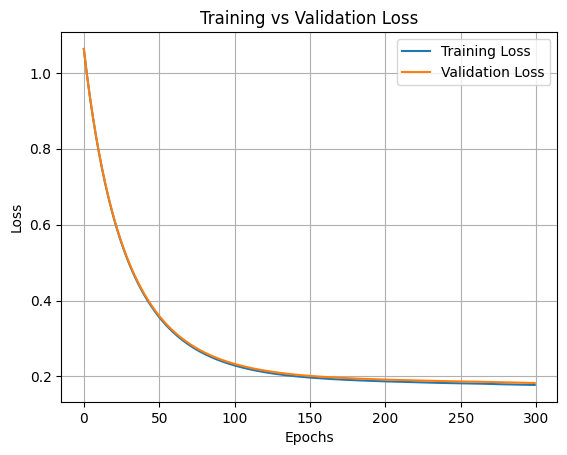

In [9]:
results = model.evals_result()

train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']

plt.figure()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [10]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Micro F1:", f1_score(y_test, model.predict(X_test), average='micro'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1:", f1_score(y_test, model.predict(X_test), average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.9070666666666667
Micro F1: 0.9070666666666667
Macro F1: 0.9069017276411162
Weighted F1: 0.9069017276411161
ROC-AUC: 0.9828945200000001


In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     10000
    DoS_ATTACK       0.89      0.82      0.85     10000
NON_DoS_ATTACK       0.83      0.90      0.87     10000

      accuracy                           0.91     30000
     macro avg       0.91      0.91      0.91     30000
  weighted avg       0.91      0.91      0.91     30000



In [12]:
benign_mask = (y_test_arr == 0)
X_test_benign = X_test.values[benign_mask]
X_test_attacks = X_test.values[~benign_mask]
print(f'Test benign : {len(X_test_benign):,}')
print(f'Test attacks: {len(X_test_attacks):,}')

Test benign : 10,000
Test attacks: 20,000


In [13]:
def benign_fpr(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    benign = y_true == 0
    return float((y_pred[benign] != 0).mean()) if benign.any() else 0.0

In [14]:
def macro_pr(y_true, y_pred, K=3):          # macro precision, macro recall via confusion matrix
    cm = np.bincount(y_true*K + y_pred, minlength=K*K).reshape(K, K).astype(float)
    d = np.diag(cm); col = cm.sum(0); row = cm.sum(1)
    prec = np.where(col > 0, d/col, 0).mean()
    rec  = np.where(row > 0, d/row, 0).mean()
    return float(prec), float(rec)

In [15]:
def mf1(y_true, y_pred, K=3):
    cm = np.bincount(y_true*K + y_pred, minlength=K*K).reshape(K, K).astype(float); d = np.diag(cm)
    den = 2*d + (cm.sum(0)-d) + (cm.sum(1)-d)
    present = cm.sum(1) > 0 
    f = np.divide(2*d, den, out=np.zeros_like(d), where=den > 0)
    return float(f[present].mean()) if present.any() else 0.0

In [16]:
def load_adv_xy(path):
    d = pd.read_csv(path)
    Xa = d.drop(columns=['true_label','pred_clean','pred_adv','y_pred','confidence'],
                errors='ignore').select_dtypes(include=[np.number])
    Xa.replace([np.inf, -np.inf], np.nan, inplace=True); Xa.fillna(0, inplace=True)
    Xa = Xa.reindex(columns=X_train.columns, fill_value=0).astype('float32')
    return Xa.values, d['true_label'].values.astype(int)

In [17]:
def compose_mc(Xb, Xa, ya, alpha, rng):
    n = min(len(Xb), len(Xa)); na = int(alpha*n); nl = n - na
    il = rng.choice(len(Xb), nl, replace=False); ia = rng.choice(len(Xa), na, replace=(na > len(Xa)))
    X = np.vstack([Xb[il], Xa[ia]]); y = np.concatenate([np.zeros(nl, int), ya[ia]])
    s = rng.permutation(len(X)); return X[s], y[s]

In [18]:
SOURCES = [
    ('Control (clean)', X_test_attacks),
    ('Epsilon = 0.01',  load_adv('data/adversarial_full_epsilon_0.01.csv')),
    ('Epsilon = 0.05',  load_adv('data/adversarial_full_epsilon_0.05.csv')),
    ('Epsilon = 0.10',  load_adv('data/adversarial_full_epsilon_0.1.csv')),
    ('Epsilon = 0.50',  load_adv('data/adversarial_full_epsilon_0.5.csv')),
]

In [19]:
for name, arr in SOURCES:
    print(f'  {name:<22}  attack samples available: {len(arr):,}')
print(f'\n{"Epsilon":<22}  {"Alpha":>6}  {"Evasion%":>10}  {"Detect%":>10}'
      f'  {"Detect 95% CI":^20}  {"FPR%":>8}')
print('-' * 88)
rows_det = []
for eps_name, X_adv in SOURCES:
    for alpha in ALPHAS:
        X_mix, y_mix = compose(X_test_benign, X_adv, alpha, RNG)
        preds  = model.predict(X_mix)
        adv_m = y_mix == 1
        ben_m = y_mix == 0
        ev_rate  = (preds[adv_m] == 0).mean() if adv_m.sum() > 0 else 0.0
        det_rate = (preds[adv_m] != 0).mean() if adv_m.sum() > 0 else 1.0
        fpr      = (preds[ben_m] != 0).mean() if ben_m.sum() > 0 else 0.0
        dr_b = []
        for _ in range(N_BOOT):
            bi  = RNG.integers(0, len(X_mix), size=len(X_mix))
            pm  = y_mix[bi] == 1
            dr_b.append((preds[bi][pm] != 0).mean() if pm.sum() > 0 else 1.0)
        dr_lo = np.percentile(dr_b, 2.5)
        dr_hi = np.percentile(dr_b, 97.5)
        rows_det.append({
            'epsilon':    eps_name,
            'alpha':      alpha,
            'n_mixed':    len(X_mix),
            'n_adv':      int(adv_m.sum()),
            'n_ben':      int(ben_m.sum()),
            'evasion':    round(float(ev_rate),  4),
            'detection':  round(float(det_rate), 4),
            'dr_lo':      round(float(dr_lo),    4),
            'dr_hi':      round(float(dr_hi),    4),
            'fpr':        round(float(fpr),      4),
        })
        print(f'{eps_name:<22}  {alpha:>6.1f}  {ev_rate*100:>9.1f}%  '
              f'{det_rate*100:>9.1f}%  [{dr_lo*100:.1f}, {dr_hi*100:.1f}]'
              f'  {fpr*100:>7.3f}%')
    print()

  Control (clean)         attack samples available: 20,000
  Epsilon = 0.01          attack samples available: 225,000
  Epsilon = 0.05          attack samples available: 225,000
  Epsilon = 0.10          attack samples available: 225,000
  Epsilon = 0.50          attack samples available: 225,000

Epsilon                  Alpha    Evasion%     Detect%     Detect 95% CI          FPR%
----------------------------------------------------------------------------------------
Control (clean)            0.0        0.0%      100.0%  [100.0, 100.0]    0.000%
Control (clean)            0.1        0.0%      100.0%  [100.0, 100.0]    0.000%
Control (clean)            0.2        0.1%      100.0%  [99.8, 100.0]    0.000%
Control (clean)            0.3        0.0%      100.0%  [100.0, 100.0]    0.000%
Control (clean)            0.5        0.0%      100.0%  [99.9, 100.0]    0.000%
Control (clean)            0.7        0.0%      100.0%  [100.0, 100.0]    0.000%
Control (clean)            0.9        0.

In [20]:
X_test_benign = X_test.values[y_test_arr == 0]
_aX, _ay = X_test.values[y_test_arr != 0], y_test_arr[y_test_arr != 0]
SOURCES_MC = [('Control (clean)', _aX, _ay)]
for _nm, _p in [('Epsilon = 0.01', 'data/adversarial_full_epsilon_0.01.csv'),
                ('Epsilon = 0.05', 'data/adversarial_full_epsilon_0.05.csv'),
                ('Epsilon = 0.10', 'data/adversarial_full_epsilon_0.1.csv'),
                ('Epsilon = 0.50', 'data/adversarial_full_epsilon_0.5.csv')]:
    _X, _y = load_adv_xy(_p); _m = _y != 0
    SOURCES_MC.append((_nm, _X[_m], _y[_m]))
ALPHAS_MC = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]

rows_mc = {}
for name, Xa, ya in SOURCES_MC:
    for a in ALPHAS_MC:
        Xm, ym = compose_mc(X_test_benign, Xa, ya, a, RNG); pr = model.predict(Xm)
        b = np.array([mf1(ym[i], pr[i]) for i in (RNG.integers(0, len(ym), len(ym)) for _ in range(N_BOOT))])
        rows_mc[(name, a)] = dict(mf1=round(mf1(ym, pr), 4),
                                  lo=round(float(np.percentile(b, 2.5)), 4),
                                  hi=round(float(np.percentile(b, 97.5)), 4))
nrej = 0
for name, *_ in SOURCES_MC[1:]:
    for a in ALPHAS_MC:
        e, c = rows_mc[(name, a)], rows_mc[('Control (clean)', a)]
        if e['hi'] < c['lo'] or e['lo'] > c['hi']: nrej += 1
print(f"H3: reject H3_0 in {nrej} of {4*len(ALPHAS_MC)} conditions ->",
      "reject H3_0" if nrej else "fail to reject H3_0")

H3: reject H3_0 in 28 of 28 conditions -> reject H3_0


detection% at alpha=1.0: [np.float64(72.4), np.float64(90.2), np.float64(98.2), np.float64(99.5)] (expect 72.4 / 90.2 / 98.2 / 99.5)


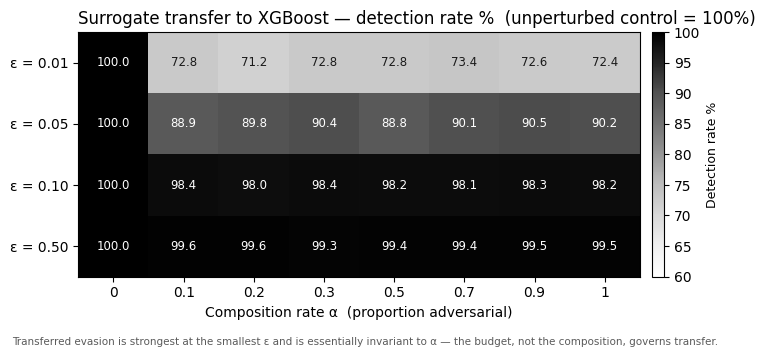

wrote Figure28b_RQ3_detection.png and Figures/data/rq3_detection.json


In [21]:
EPS_ORDER = ["Epsilon = 0.01", "Epsilon = 0.05", "Epsilon = 0.10", "Epsilon = 0.50"]
alphas = sorted({r["alpha"] for r in rows_det})
det = np.full((len(EPS_ORDER), len(alphas)), np.nan)
eva = np.full((len(EPS_ORDER), len(alphas)), np.nan)
for r in rows_det:
    if r["epsilon"] in EPS_ORDER:
        i = EPS_ORDER.index(r["epsilon"]); j = alphas.index(r["alpha"])
        det[i, j] = r["detection"] * 100
        eva[i, j] = r["evasion"] * 100
a1 = alphas.index(1.0) if 1.0 in alphas else -1
print("detection% at alpha=1.0:", [round(det[i, a1], 1) for i in range(len(EPS_ORDER))], "(expect 72.4 / 90.2 / 98.2 / 99.5)")
INK = "#1a1a1a"
fig, ax = plt.subplots(figsize=(7.4, 3.4))
im = ax.imshow(det, cmap="Greys", vmin=60, vmax=100, aspect="auto")   # darker = better detection
ax.set_xticks(range(len(alphas))); ax.set_xticklabels([f"{a:g}" for a in alphas])
ax.set_yticks(range(len(EPS_ORDER))); ax.set_yticklabels([e.replace("Epsilon = ", "ε = ") for e in EPS_ORDER])
ax.set_xlabel("Composition rate α  (proportion adversarial)")
ax.set_title("Surrogate transfer to XGBoost — detection rate %  (unperturbed control = 100%)", loc="left")
ax.grid(False)
for i in range(det.shape[0]):
    for j in range(det.shape[1]):
        v = det[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8.5, color="white" if v > 85 else INK)
fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02).set_label("Detection rate %", fontsize=9)
fig.text(0.5, -0.03, "Transferred evasion is strongest at the smallest ε and is essentially "
                     "invariant to α — the budget, not the composition, governs transfer.",
         ha="center", fontsize=7.5, color="#5a5a5a")
fig.tight_layout()
os.makedirs("Figures", exist_ok=True)
fig.savefig("Figures/Figure28b_RQ3_detection.png", dpi=300, bbox_inches="tight")
plt.show()
os.makedirs("Figures/data", exist_ok=True)
json.dump({"metric": "detection_pct",
           "alphas": [float(a) for a in alphas],
           "epsilons": [0.01, 0.05, 0.10, 0.50],
           "detection": [[None if np.isnan(v) else float(v) for v in row] for row in det],
           "evasion":   [[None if np.isnan(v) else float(v) for v in row] for row in eva]},
          open("Figures/data/rq3_detection.json", "w"), indent=2)
print("wrote Figure28b_RQ3_detection.png and Figures/data/rq3_detection.json")

Condition           a   macro F1        95% CI
--------------------------------------------------
Epsilon = 0.01    0.1   0.7851  [0.7654, 0.8045]
Epsilon = 0.01    0.2   0.7754  [0.7612, 0.7894]
Epsilon = 0.01    0.3   0.7807  [0.7690, 0.7921]
Epsilon = 0.01    0.5   0.7728  [0.7639, 0.7816]
Epsilon = 0.01    0.7   0.7731  [0.7658, 0.7805]
Epsilon = 0.01    0.9   0.7786  [0.7719, 0.7852]
Epsilon = 0.01    1.0   0.6651  [0.6554, 0.6746]
Epsilon = 0.05    0.1   0.7485  [0.7278, 0.7693]
Epsilon = 0.05    0.2   0.7488  [0.7341, 0.7634]
Epsilon = 0.05    0.3   0.7458  [0.7334, 0.7574]
Epsilon = 0.05    0.5   0.7548  [0.7456, 0.7641]
Epsilon = 0.05    0.7   0.7481  [0.7401, 0.7557]
Epsilon = 0.05    0.9   0.7564  [0.7495, 0.7632]
Epsilon = 0.05    1.0   0.6266  [0.6169, 0.6363]
Epsilon = 0.10    0.1   0.7468  [0.7263, 0.7669]
Epsilon = 0.10    0.2   0.7363  [0.7217, 0.7503]
Epsilon = 0.10    0.3   0.7414  [0.7297, 0.7530]
Epsilon = 0.10    0.5   0.7229  [0.7135, 0.7323]
Epsilon = 0.10    0.

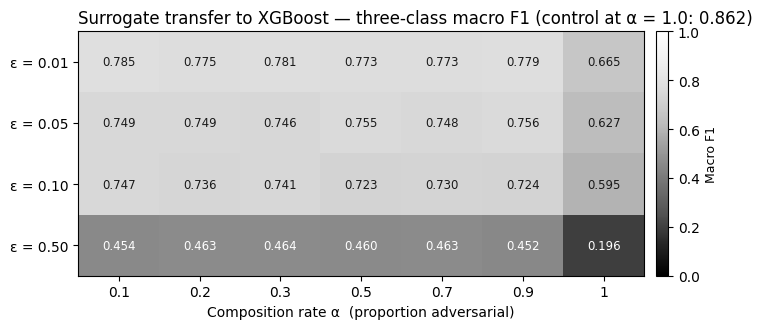

wrote Figure28a_RQ3_macroF1.png and Figures/data/rq3_macrof1.json


In [22]:
EPS = ['Epsilon = 0.01', 'Epsilon = 0.05', 'Epsilon = 0.10', 'Epsilon = 0.50']
control = [rows_mc[('Control (clean)', a)]['mf1'] for a in ALPHAS_MC]
grid = np.array([[rows_mc[(nm, a)]['mf1'] for a in ALPHAS_MC] for nm in EPS])
print(f"{'Condition':<16}{'a':>5}   macro F1        95% CI"); print('-' * 50)
for nm in EPS:
    for a in ALPHAS_MC:
        r = rows_mc[(nm, a)]
        print(f"{nm:<16}{a:>5}   {r['mf1']:.4f}  [{r['lo']:.4f}, {r['hi']:.4f}]")
a1 = ALPHAS_MC.index(1.0)
print(f"\nalpha=1.0  control = {control[a1]:.4f}  adversarial =",
      [round(grid[i, a1], 4) for i in range(len(EPS))],
      "\n(manuscript: 0.856 -> 0.668 / 0.628 / 0.588 / 0.198 — verify)")
INK = "#1a1a1a"
fig, ax = plt.subplots(figsize=(7.4, 3.4))
im = ax.imshow(grid, cmap="Greys_r", vmin=0, vmax=1, aspect="auto")   # lighter = higher F1
ax.set_xticks(range(len(ALPHAS_MC))); ax.set_xticklabels([f"{a:g}" for a in ALPHAS_MC])
ax.set_yticks(range(len(EPS))); ax.set_yticklabels([e.replace("Epsilon = ", "ε = ") for e in EPS])
ax.set_xlabel("Composition rate α  (proportion adversarial)")
ax.set_title(f"Surrogate transfer to XGBoost — three-class macro F1 "
             f"(control at α = 1.0: {control[a1]:.3f})", loc="left")
ax.grid(False)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8.5, color="white" if v < 0.5 else INK)
fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02).set_label("Macro F1", fontsize=9)
fig.tight_layout()
os.makedirs("Figures", exist_ok=True)
fig.savefig("Figures/Figure28a_RQ3_macroF1.png", dpi=300, bbox_inches="tight")
plt.show()
os.makedirs("Figures/data", exist_ok=True)
json.dump({"metric": "macro_f1", "alphas": [float(a) for a in ALPHAS_MC],
           "epsilons": [0.01, 0.05, 0.10, 0.50],
           "macro_f1": [[float(v) for v in row] for row in grid],
           "control": [float(v) for v in control]},
          open("Figures/data/rq3_macrof1.json", "w"), indent=2)
print("wrote Figure28a_RQ3_macroF1.png and Figures/data/rq3_macrof1.json")